## Bloque 0 — Imports

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Bloque 1 — Carga

In [67]:
from pathlib import Path

# Cambiar según el formato de los archivos fuente: 'csv' o 'xlsx'
FORMAT = 'xlsx'

COL_MAP = {
    'Fecha y Hora': 'time_index_colombia',
    'ID Entidad':   'entity_id',
}

if FORMAT == 'csv':
    files = sorted(Path('.').glob('*.csv'))
    def load(f):
        return pd.read_csv(f, sep=';', low_memory=False)

elif FORMAT == 'xlsx':
    files = sorted(Path('.').glob('*.xlsx'))
    def load(f):
        return pd.read_excel(f)

print(f'{len(files)} archivos encontrados:')
for f in files:
    print(' ', f.name)

partes = []
for f in files:
    chunk = load(f)
    chunk.rename(columns=COL_MAP, inplace=True)
    partes.append(chunk)

df = pd.concat(partes, join='outer', ignore_index=True)

# Avisar si algún archivo tiene columnas distintas al resto
col_sets = [set(p.columns) for p in partes]
extra = set.union(*col_sets) - set.intersection(*col_sets)
if extra:
    print('Columnas inconsistentes entre archivos:', extra)

print(f'Shape combinado: {df.shape}')
df.head()

7 archivos encontrados:
  etsmartmeter_2026-03-12_17-47-37.xlsx
  etsmartmeter_2026-03-12_17-49-36_parte_2.xlsx
  etsmartmeter_2026-03-12_17-51-33_parte_3.xlsx
  etsmartmeter_2026-03-12_17-53-27_parte_4.xlsx
  etsmartmeter_2026-03-12_17-55-22_parte_5.xlsx
  etsmartmeter_2026-03-12_17-57-15_parte_6.xlsx
  etsmartmeter_2026-03-12_17-59-20_parte_7.xlsx
Shape combinado: (639131, 50)


,entity_id,Tipo Entidad,time_index_colombia,fiware_servicepath,__original_ngsi_entity__,instanceid,v1,v2,v3,i1,...,reactiveenergyexportday,activepower1,activepower2,activepower3,activepower,reactivepower1,reactivepower2,reactivepower3,reactivepower,clock
0,SmartMeter_SM_B10_ARQ,SmartMeter,2026-02-10 00:01:09,/,NaN,urn:ngsi-ld:9e0a87a2-c3b8-451a-a089-bd062e1049b1,125.89,126.85,127.37,25.1,...,40.99,2799.0,2140.9,1752.0,6692.7,1458.0,1115.8,1283.1,3857.1,1.770682e+12
1,SmartMeter_SM_B12_DERE,SmartMeter,2026-02-10 00:01:09,/,NaN,urn:ngsi-ld:dd9a6997-e202-4ab5-bd5b-df8b2f0021aa,123.82,124.58,123.91,17.4,...,0.61,209.5,1580.2,1834.0,3209.2,2094.2,2987.1,617.6,4463.7,1.770682e+12
2,SmartMeter_SM_B17_POLI,SmartMeter,2026-02-10 00:01:09,/,NaN,urn:ngsi-ld:a5a29398-6f6b-49f3-aacf-4e5f350a3668,130.14,130.55,129.53,7.5,...,28.67,776.1,777.5,1094.0,2646.4,551.1,362.9,957.1,1871.2,1.770682e+12
3,SmartMeter_SM_B18_PARQ,SmartMeter,2026-02-10 00:01:09,/,NaN,urn:ngsi-ld:d27fd9f9-134c-41a1-bed6-9374790b7646,132.14,131.50,132.07,30.0,...,37.17,4793.6,4515.4,2770.0,12079.1,1670.4,349.2,854.2,2174.7,1.770682e+12
4,SmartMeter_SM_B3_RECT,SmartMeter,2026-02-10 00:01:09,/,NaN,urn:ngsi-ld:87fc332e-5e30-4801-9cd3-273ce77e3b69,127.88,128.72,128.50,5.3,...,1.44,610.8,398.3,538.0,1547.7,48.2,206.7,28.9,187.4,1.770682e+12


## Bloque 2 — Conversión de tipos y selección de columnas

In [68]:
COLS = ['time_index_colombia', 'entity_id', 'activepower', 'totalpowerfactor',
        'relativethdvoltage', 'activeenergyimport', 'v1', 'v2', 'v3']
df = df[COLS].copy()

df['time_index_colombia'] = pd.to_datetime(df['time_index_colombia'], utc=False, format='%d/%m/%Y %H:%M')
df['entity_id'] = df['entity_id'].astype('category')

num_cols = ['activepower', 'totalpowerfactor', 'relativethdvoltage', 'activeenergyimport', 'v1', 'v2', 'v3']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

time_index_colombia    datetime64[ns]
entity_id                    category
activepower                   float64
totalpowerfactor              float64
relativethdvoltage            float64
activeenergyimport            float64
v1                            float64
v2                            float64
v3                            float64
dtype: object


## Bloque 3 — Descripción estadística

### 3.1 Info

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639131 entries, 0 to 639130
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   time_index_colombia  639131 non-null  datetime64[ns]
 1   entity_id            639131 non-null  category      
 2   activepower          639077 non-null  float64       
 3   totalpowerfactor     639077 non-null  float64       
 4   relativethdvoltage   639077 non-null  float64       
 5   activeenergyimport   639077 non-null  float64       
 6   v1                   639077 non-null  float64       
 7   v2                   639077 non-null  float64       
 8   v3                   639077 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(7)
memory usage: 39.6 MB


In [70]:
df.describe(include='all')

,time_index_colombia,entity_id,activepower,totalpowerfactor,relativethdvoltage,activeenergyimport,v1,v2,v3
count,639131,639131,639077.000000,639077.000000,639077.000000,6.390770e+05,639077.000000,639077.000000,639077.000000
unique,NaN,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,SmartMeter_SM_B9_SFA1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,40729,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2026-03-03 07:36:29.147422976,NaN,18269.636563,0.890639,2.616911,4.890299e+07,125.045505,126.897166,126.280797
min,2026-02-10 00:01:09,NaN,0.000000,-0.810000,0.661000,5.490000e+01,107.100000,119.570000,114.570000
25%,2026-02-28 02:44:50,NaN,4113.400000,0.870000,1.494000,1.501426e+07,123.270000,124.100000,124.120000
50%,2026-03-05 16:25:45,NaN,12197.800000,0.960000,1.814000,4.152870e+07,125.310000,126.020000,125.910000
75%,2026-03-09 05:13:08,NaN,28359.300000,0.990000,2.237000,8.421743e+07,127.300000,128.460000,127.990000
max,2026-03-12 17:47:06,NaN,125934.200000,1.000000,15.866000,1.000000e+08,137.150000,144.850000,137.140000


### 3.2 — Distribución temporal y por entidad

**Celda A — Registros por día**

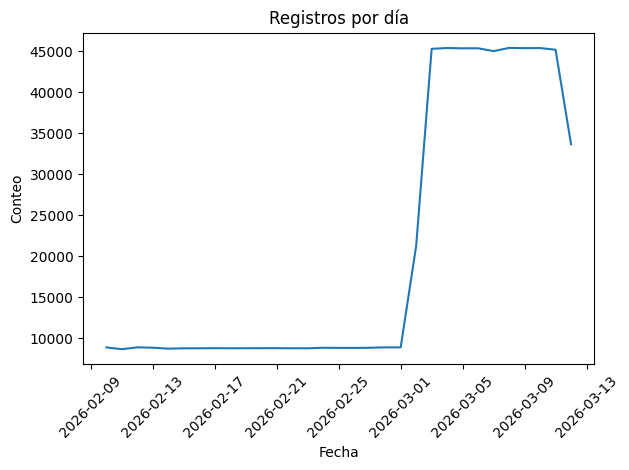

In [71]:
by_day = df.groupby(df['time_index_colombia'].dt.date).size()
fig, ax = plt.subplots()
ax.plot(by_day.index, by_day.values)
ax.set_xlabel('Fecha')
ax.set_ylabel('Conteo')
ax.set_title('Registros por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Celda B — Registros por hora del día**

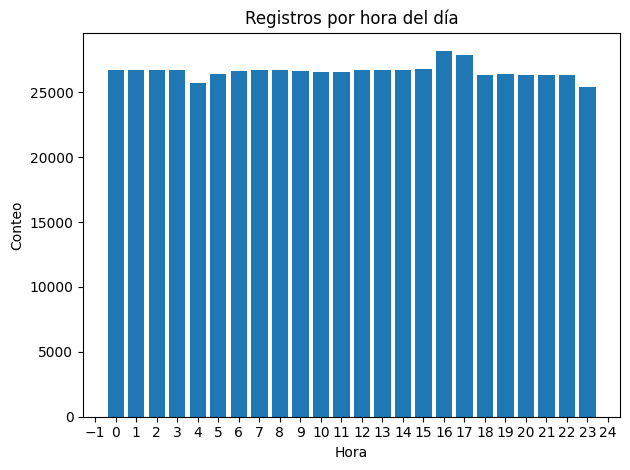

In [72]:
by_hour = df.groupby(df['time_index_colombia'].dt.hour).size()
fig, ax = plt.subplots()
ax.bar(by_hour.index, by_hour.values)
ax.set_xlabel('Hora')
ax.set_ylabel('Conteo')
ax.set_title('Registros por hora del día')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

**Celda C — Registros por entity_id**

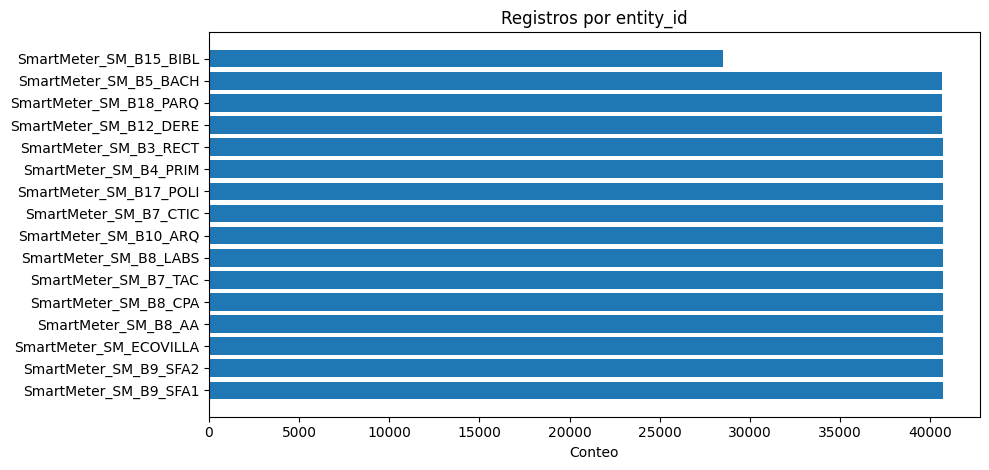

In [73]:
by_entity = df['entity_id'].value_counts()
fig, ax = plt.subplots(figsize=(10, max(4, len(by_entity) * 0.3)))
ax.barh(by_entity.index.astype(str), by_entity.values)
ax.set_xlabel('Conteo')
ax.set_title('Registros por entity_id')
plt.tight_layout()
plt.show()

### 3.3 — Distribuciones de variables numéricas

**activepower — histograma**

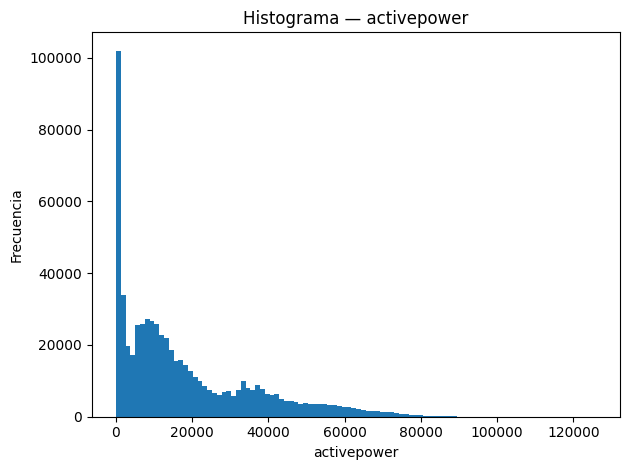

In [74]:
fig, ax = plt.subplots()
ax.hist(df['activepower'].dropna(), bins=100)
ax.set_xlabel('activepower')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — activepower')
plt.tight_layout()
plt.show()

**activepower — boxplot**

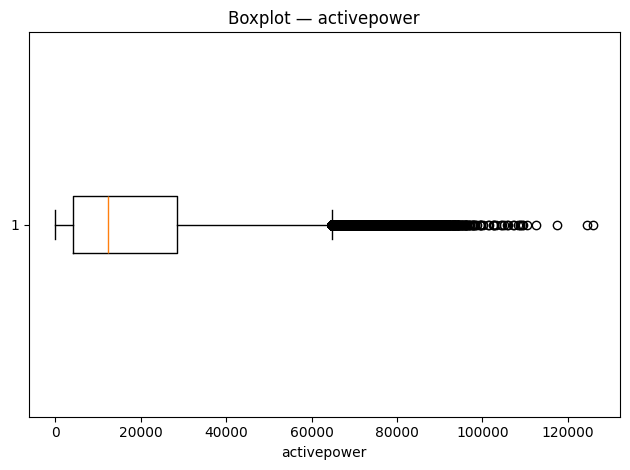

In [75]:
fig, ax = plt.subplots()
ax.boxplot(df['activepower'].dropna(), vert=False)
ax.set_xlabel('activepower')
ax.set_title('Boxplot — activepower')
plt.tight_layout()
plt.show()

**totalpowerfactor — histograma**

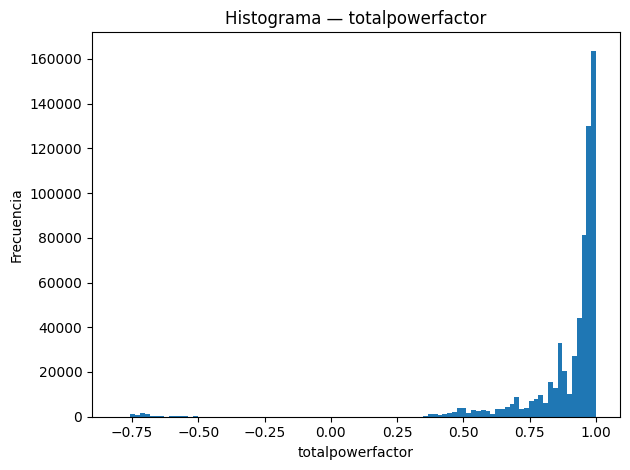

In [76]:
fig, ax = plt.subplots()
ax.hist(df['totalpowerfactor'].dropna(), bins=100)
ax.set_xlabel('totalpowerfactor')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — totalpowerfactor')
plt.tight_layout()
plt.show()

**totalpowerfactor — boxplot**

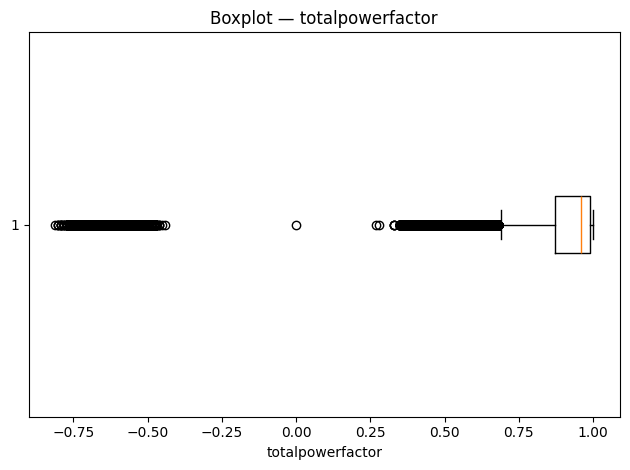

In [77]:
fig, ax = plt.subplots()
ax.boxplot(df['totalpowerfactor'].dropna(), vert=False)
ax.set_xlabel('totalpowerfactor')
ax.set_title('Boxplot — totalpowerfactor')
plt.tight_layout()
plt.show()

**relativehdvoltage — histograma**

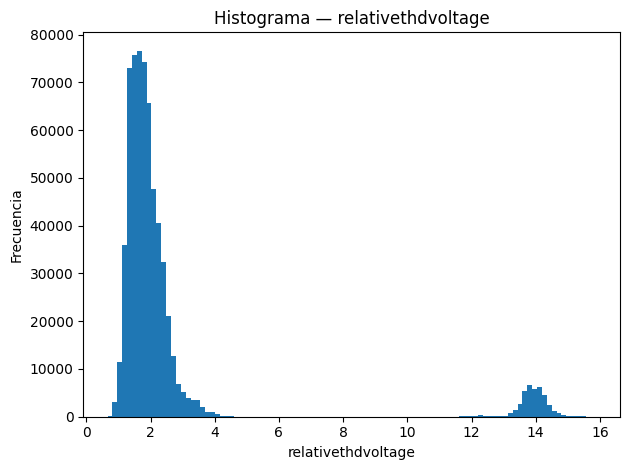

In [78]:
fig, ax = plt.subplots()
ax.hist(df['relativethdvoltage'].dropna(), bins=100)
ax.set_xlabel('relativethdvoltage')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — relativethdvoltage')
plt.tight_layout()
plt.show()

**relativehdvoltage — boxplot**

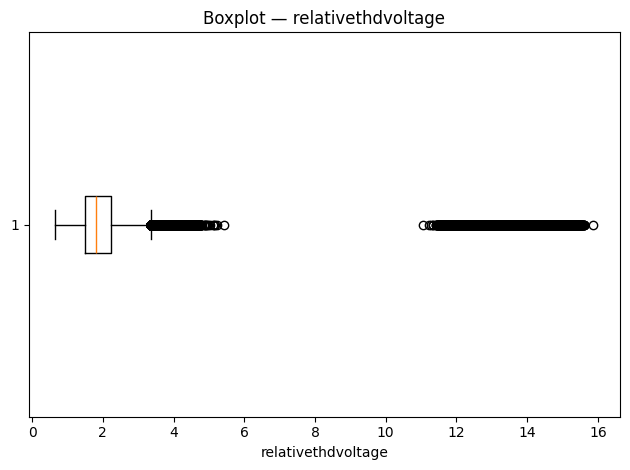

In [79]:
fig, ax = plt.subplots()
ax.boxplot(df['relativethdvoltage'].dropna(), vert=False)
ax.set_xlabel('relativethdvoltage')
ax.set_title('Boxplot — relativethdvoltage')
plt.tight_layout()
plt.show()

**activeenergyimport — histograma**

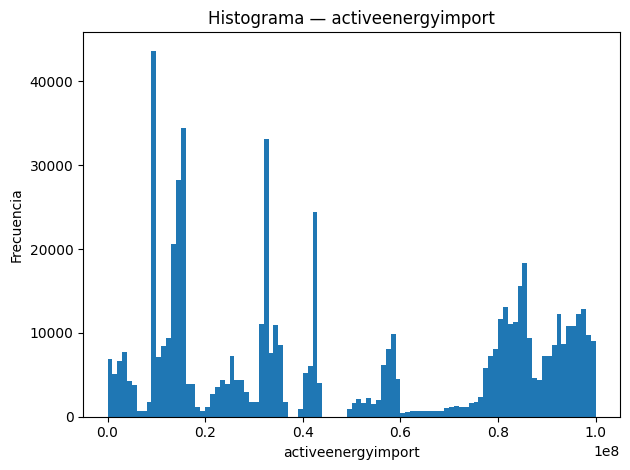

In [80]:
fig, ax = plt.subplots()
ax.hist(df['activeenergyimport'].dropna(), bins=100)
ax.set_xlabel('activeenergyimport')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — activeenergyimport')
plt.tight_layout()
plt.show()

**activeenergyimport — boxplot**

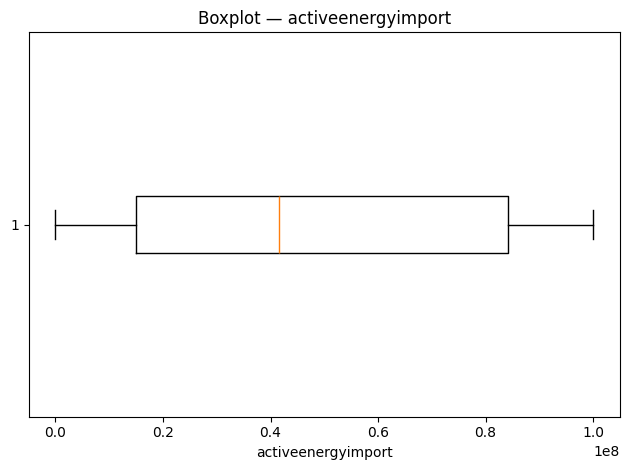

In [81]:
fig, ax = plt.subplots()
ax.boxplot(df['activeenergyimport'].dropna(), vert=False)
ax.set_xlabel('activeenergyimport')
ax.set_title('Boxplot — activeenergyimport')
plt.tight_layout()
plt.show()

**v1 — histograma**

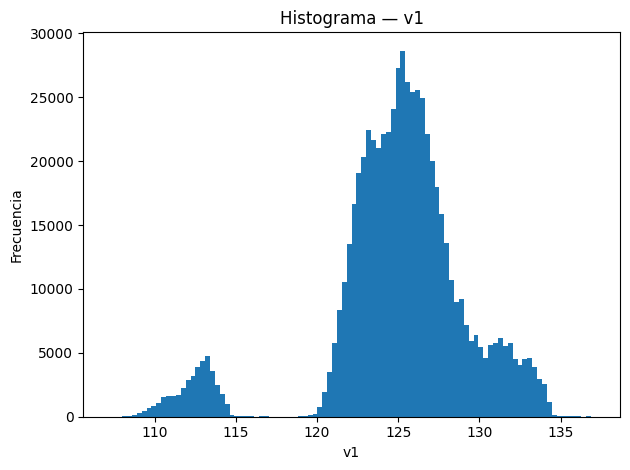

In [82]:
fig, ax = plt.subplots()
ax.hist(df['v1'].dropna(), bins=100)
ax.set_xlabel('v1')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — v1')
plt.tight_layout()
plt.show()

**v1 — boxplot**

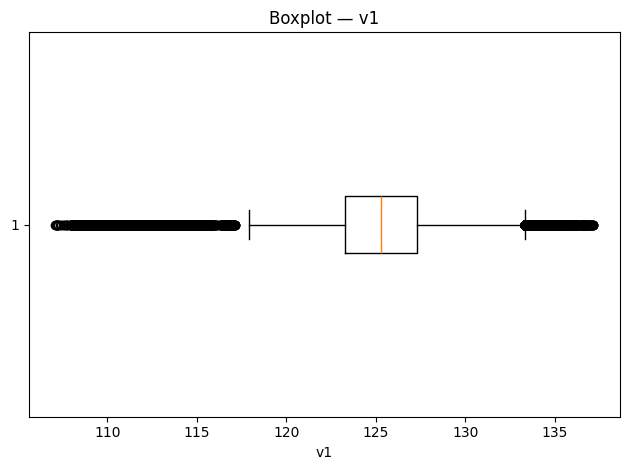

In [83]:
fig, ax = plt.subplots()
ax.boxplot(df['v1'].dropna(), vert=False)
ax.set_xlabel('v1')
ax.set_title('Boxplot — v1')
plt.tight_layout()
plt.show()

**v2 — histograma**

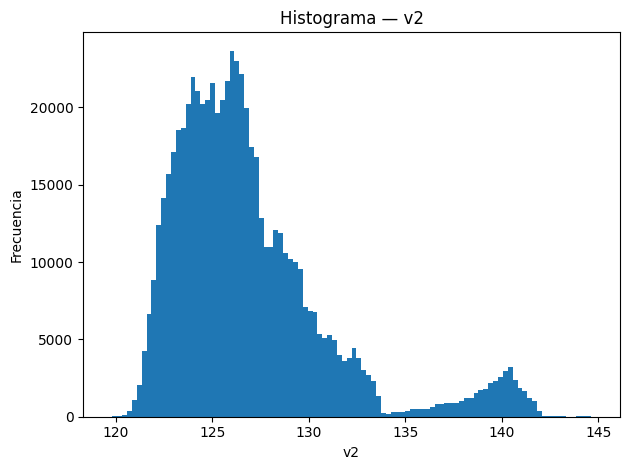

In [84]:
fig, ax = plt.subplots()
ax.hist(df['v2'].dropna(), bins=100)
ax.set_xlabel('v2')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — v2')
plt.tight_layout()
plt.show()

**v2 — boxplot**

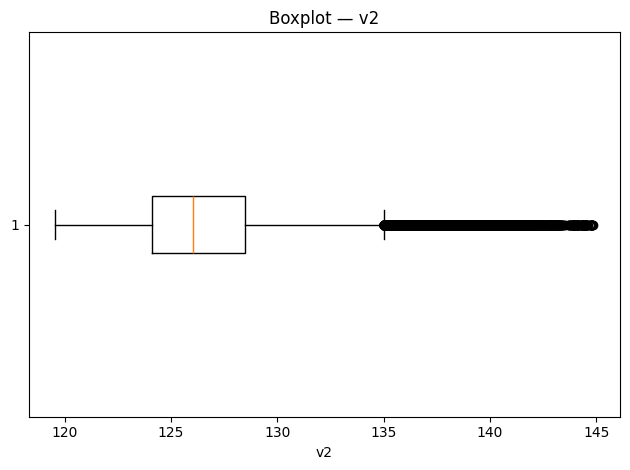

In [85]:
fig, ax = plt.subplots()
ax.boxplot(df['v2'].dropna(), vert=False)
ax.set_xlabel('v2')
ax.set_title('Boxplot — v2')
plt.tight_layout()
plt.show()

**v3 — histograma**

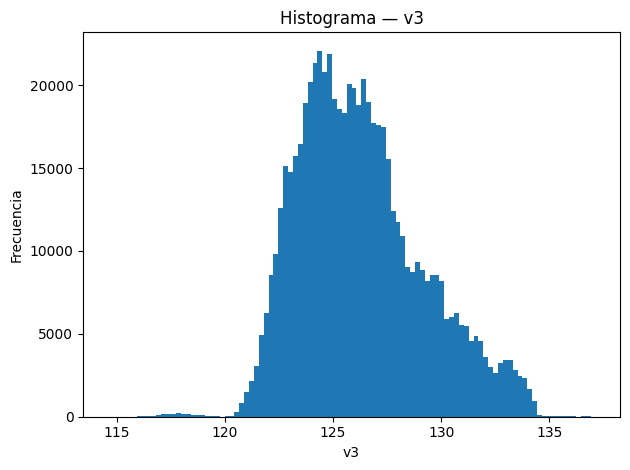

In [86]:
fig, ax = plt.subplots()
ax.hist(df['v3'].dropna(), bins=100)
ax.set_xlabel('v3')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — v3')
plt.tight_layout()
plt.show()

**v3 — boxplot**

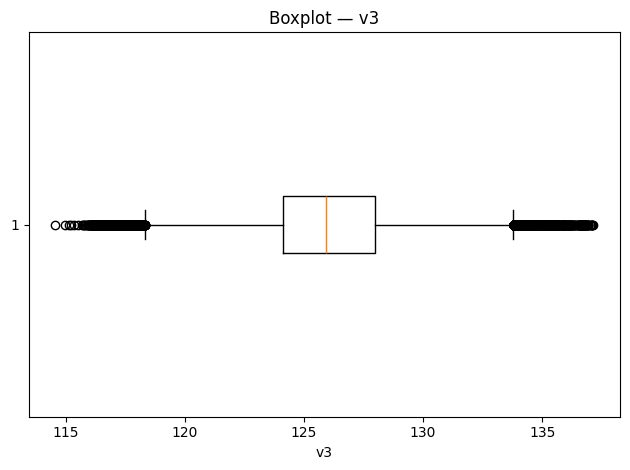

In [87]:
fig, ax = plt.subplots()
ax.boxplot(df['v3'].dropna(), vert=False)
ax.set_xlabel('v3')
ax.set_title('Boxplot — v3')
plt.tight_layout()
plt.show()

## Bloque 4 — Limpieza de atípicos

### 4.1 — Conversión a numéricos

In [88]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### 4.2 — Validación de rangos físicos

In [89]:
print('NaNs antes:')
print(df[num_cols].isna().sum())

RANGES = {
    'activeenergyimport': (0, 500_000_000),
    'relativethdvoltage':  (0, 100),
    'totalpowerfactor':   (-1.0, 1.0),
    'activepower':        (0, 2_000_000),
    'v1':                 (114.45, 133.53),
    'v2':                 (114.45, 133.53),
    'v3':                 (114.45, 133.53),
}

for col, (lo, hi) in RANGES.items():
    df[col] = df[col].where(df[col].between(lo, hi))

print('NaNs después:')
print(df[num_cols].isna().sum())

NaNs antes:
activepower           54
totalpowerfactor      54
relativethdvoltage    54
activeenergyimport    54
v1                    54
v2                    54
v3                    54
dtype: int64
NaNs después:
activepower              54
totalpowerfactor         54
relativethdvoltage       54
activeenergyimport       54
v1                    47234
v2                    40039
v3                     7729
dtype: int64


### 4.3 — Eliminación de filas sin información esencial

In [90]:
before = len(df)
df.dropna(inplace=True)
print(f'Filas eliminadas: {before - len(df)}  — shape resultante: {df.shape}')

Filas eliminadas: 48960  — shape resultante: (590171, 9)


## Bloque 5 — Resample configurable

In [91]:
FREQ = '60min'

df_resampled = (
    df.set_index('time_index_colombia')
    .groupby('entity_id', observed=True)
    .resample(FREQ)
    .agg({
        'activepower':        'mean',
        'totalpowerfactor':   'mean',
        'relativethdvoltage':  'mean',
        'v1':                 'mean',
        'v2':                 'mean',
        'v3':                 'mean',
        'activeenergyimport': 'mean',
    })
    .reset_index()
)

print(df_resampled.shape)

(10575, 9)


In [92]:
before = len(df_resampled)
df_resampled.dropna(inplace=True)
print(f'Filas eliminadas: {before - len(df_resampled)}  — shape resultante: {df_resampled.shape}')

Filas eliminadas: 38  — shape resultante: (10537, 9)


## Bloque 6 — Exportación

In [93]:
csv_path     = 'etsmartmeter_clean.csv'
parquet_path = 'etsmartmeter_clean.parquet'

df_resampled.to_csv(csv_path, index=False)
df_resampled.to_parquet(parquet_path, engine='pyarrow', index=False)

print(f'CSV guardado en:     {csv_path}  — shape: {df_resampled.shape}')
print(f'Parquet guardado en: {parquet_path}  — shape: {df_resampled.shape}')

CSV guardado en:     etsmartmeter_clean.csv  — shape: (10537, 9)
Parquet guardado en: etsmartmeter_clean.parquet  — shape: (10537, 9)
